# DNA Virus Genomes: Differential abundance analysis

## Microbiome Association Detection with MaAsLin2 (Microbiome Multivariable Associations with Linear Models)

In [2]:
#Load MaAsLin 2 package into the R environment
library(Maaslin2)
library(ggplot2)
library(dplyr)

## DNA viral community

In [7]:
# RNA Genes - eggnog

setwd("path/")


In [8]:
# Parsing input table

dna_virus <- read.table('data/DNA_Viruses_119.txt', header=T, sep="\t")
rownames(dna_virus) <- make.names(dna_virus$Genomes, unique = TRUE)  # set up row names

dna_virus.1 <- data.frame(dna_virus[, 2:27])

trans <- t(dna_virus.1 )
head(trans)


,DNA_Adenoviridae_like_336,DNA_Family_unknown_240,DNA_Peduoviridae_548,DNA_Family_unknown_9930,DNA_Peduoviridae_6682,DNA_Peduoviridae_3525,DNA_Peduoviridae_2089,DNA_Peduoviridae_259,DNA_Peduoviridae_2289,DNA_Family_unknown_1938,⋯,DNA_Herelleviridae_843,DNA_Myoviridae_3662,DNA_Siphoviridae_6819,DNA_Podoviridae_8103,DNA_Family_unknown_6572,DNA_Podoviridae_2003,DNA_Siphoviridae_15338,DNA_Myoviridae_5100,DNA_Siphoviridae_715,DNA_Siphoviridae_3769
Unmanip_1,36.0,22.1,22.0,20.6,20.3,20.7,17.0,14.0,14.9,13.3,⋯,4.4,7.3,0.0,5.6,6.8,0.0,0,4.2,10.2,13.0
Unmanip_3,52.2,25.6,15.9,20.5,20.6,19.3,13.6,17.7,13.9,16.4,⋯,3.7,6.8,4.4,5.1,12.7,0.0,0,4.8,13.7,10.4
Unmanip_4,37.3,21.8,19.9,18.3,17.1,18.5,15.5,17.1,13.7,10.3,⋯,5.3,9.4,0.0,0.0,6.4,4.6,0,0.0,10.2,9.2
Unmanip_5,50.1,18.0,11.4,29.4,14.1,15.0,9.2,14.6,11.0,11.7,⋯,0.0,5.6,4.7,5.2,11.1,1.9,0,0.0,9.1,10.0
Unmanip_7,52.6,22.7,15.3,23.5,19.5,19.8,11.9,17.1,14.9,11.3,⋯,0.0,6.1,5.0,5.8,8.4,0.0,0,4.5,9.7,10.2
Unmanip_8,51.1,22.1,14.1,24.2,17.9,19.7,11.3,16.9,14.6,10.9,⋯,0.0,5.7,5.0,6.0,8.2,0.0,0,4.0,9.6,8.8


In [10]:
## Parsing Metadata table

dnaVirus_samples <- read.table("data/DNA_group_samples.txt", header=TRUE, sep="\t")

rownames(dnaVirus_samples) <- make.names(dnaVirus_samples$Sample, unique = TRUE)

dnaVirus_samples.1 <- data.frame(dnaVirus_samples[, 1:2])
head(dnaVirus_samples.1)


,Samples,Condition
,<chr>,<chr>
Unmanip_1,Unmanip_1,Unmanip
Unmanip_3,Unmanip_3,Unmanip
Unmanip_4,Unmanip_4,Unmanip
Unmanip_5,Unmanip_5,Unmanip
Unmanip_7,Unmanip_7,Unmanip
Unmanip_8,Unmanip_8,Unmanip


### DNA Viral Genomes differential abundance (MaAsLin2)

[1] "Creating output folder"
[1] "Creating output figures folder"
2026-10-04 17:33:24 INFO::Writing function arguments to log file
2026-10-04 17:33:24 INFO::Verifying options selected are valid
2026-10-04 17:33:24 INFO::Determining format of input files
2026-10-04 17:33:24 INFO::Input format is data samples as rows and metadata samples as rows
2026-10-04 17:33:24 INFO::Formula for fixed effects: expr ~  Condition
2026-10-04 17:33:24 INFO::Filter data based on min abundance and min prevalence
2026-10-04 17:33:24 INFO::Total samples in data: 26
2026-10-04 17:33:24 INFO::Min samples required with min abundance for a feature not to be filtered: 0.260000
2026-10-04 17:33:24 INFO::Total filtered features: 0
2026-10-04 17:33:24 INFO::Filtered feature names from abundance and prevalence filtering:
2026-10-04 17:33:24 INFO::Total filtered features with variance filtering: 0
2026-10-04 17:33:24 INFO::Filtered feature names from variance filtering:
2026-10-04 17:33:24 INFO::Running selected norma

Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”


2026-10-04 17:33:27 INFO::Writing association plots (one for each significant association) to output folder: Maaslin2_DNA_LM_q01
2026-10-04 17:33:27 INFO::Plotting associations from most to least significant, grouped by metadata
2026-10-04 17:33:27 INFO::Plotting data for metadata number 1, Condition
2026-10-04 17:33:27 INFO::Creating boxplot for categorical data, Condition vs DNA_Peduoviridae_6682
2026-10-04 17:33:28 INFO::Creating boxplot for categorical data, Condition vs DNA_Peduoviridae_10920
2026-10-04 17:33:28 INFO::Creating boxplot for categorical data, Condition vs DNA_Peduoviridae_2089
2026-10-04 17:33:28 INFO::Creating boxplot for categorical data, Condition vs DNA_Peduoviridae_2941
2026-10-04 17:33:29 INFO::Creating boxplot for categorical data, Condition vs DNA_Peduoviridae_548
2026-10-04 17:33:29 INFO::Creating boxplot for categorical data, Condition vs DNA_Family_unknown_1595
2026-10-04 17:33:30 INFO::Creating boxplot for categorical data, Condition vs DNA_Peduoviridae_7

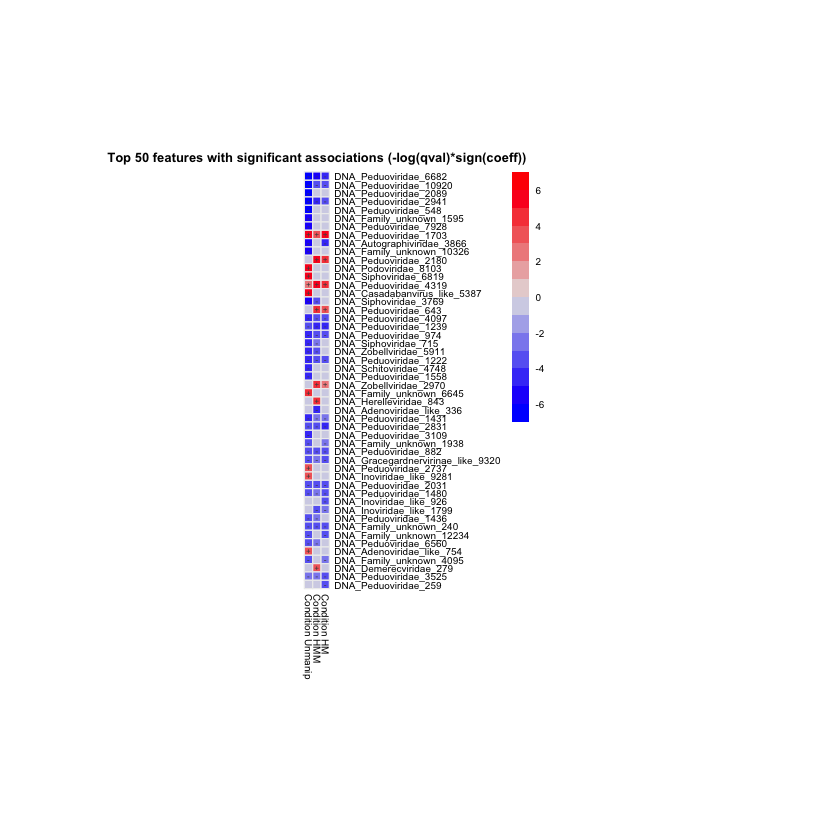

In [11]:
fit_data2 = Maaslin2(input_data     = trans, 
                     input_metadata = dnaVirus_samples.1, 
                     min_prevalence = 0.01,
                     max_significance = 0.1,
                     normalization  = "TSS",
                     correction = "BH",
                     transform = "LOG",
                     analysis_method = "LM",
                     output         = "Maaslin2_DNA_LM_q01", 
                     fixed_effects  = "Condition",
                     reference      = c("Condition,LM"),
                     plot_heatmap = TRUE,
                     plot_scatter = TRUE,
                     heatmap_first_n = 50,
                     standardize = FALSE)

